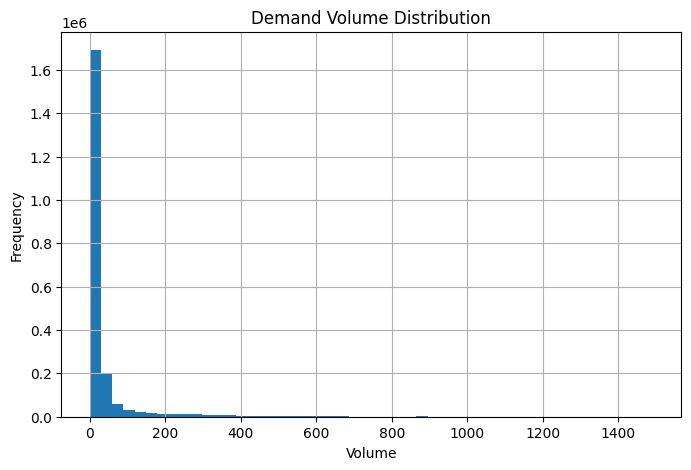

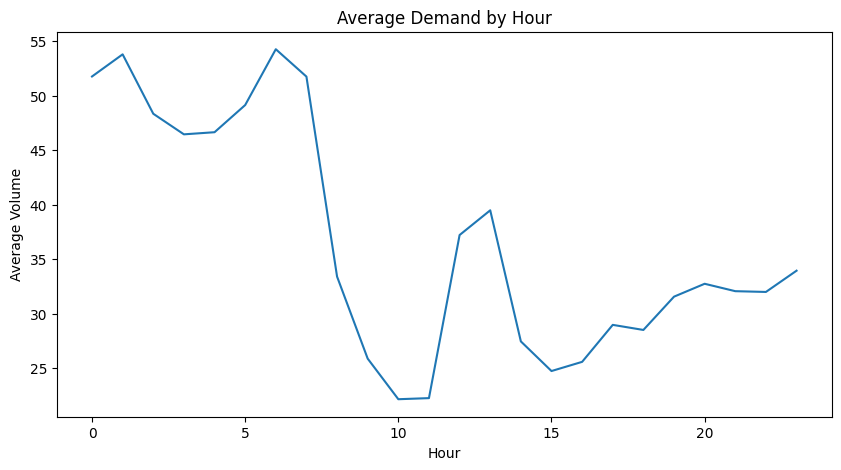

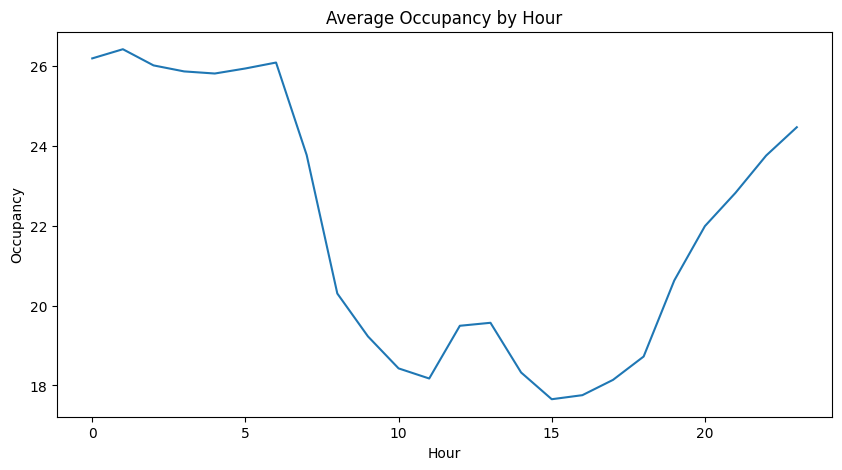

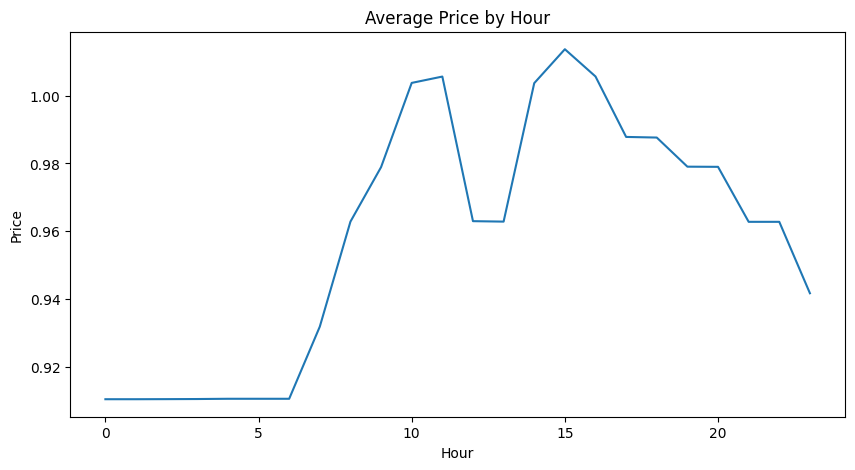

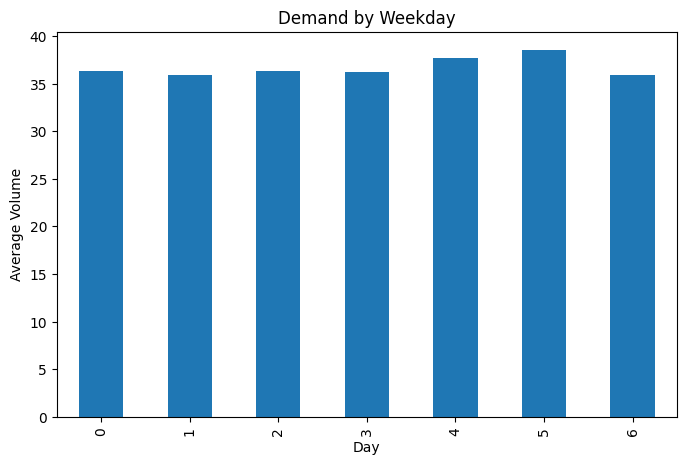

grid
595     736.958895
1131    611.374595
1167    497.286254
633     441.480751
1137    388.334273
576     366.622762
333     293.836927
1026    265.702572
775     249.704807
690     226.762567
Name: volume, dtype: float64


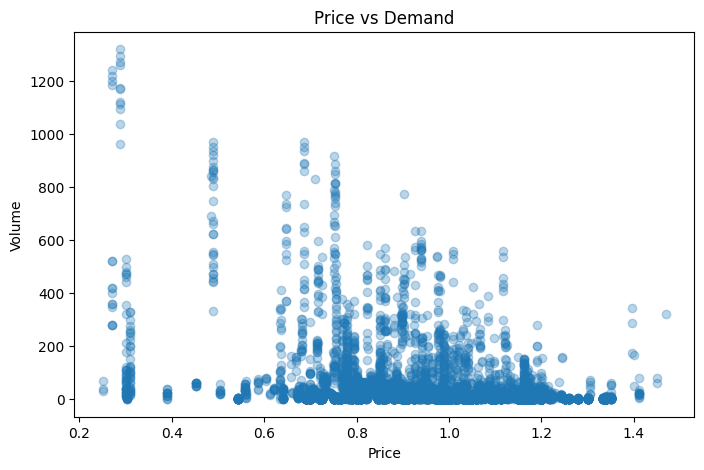

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("urbanev_merged.csv")

df["datetime"] = pd.to_datetime(df["datetime"])

df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.dayofweek


plt.figure(figsize=(8,5))
df["volume"].hist(bins=50)

plt.title("Demand Volume Distribution")
plt.xlabel("Volume")
plt.ylabel("Frequency")

plt.show()

hourly = df.groupby("hour")["volume"].mean()

plt.figure(figsize=(10,5))
hourly.plot()

plt.title("Average Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Volume")

plt.show()
hourly_occ = df.groupby("hour")["occupancy"].mean()

plt.figure(figsize=(10,5))
hourly_occ.plot()

plt.title("Average Occupancy by Hour")
plt.xlabel("Hour")
plt.ylabel("Occupancy")

plt.show()

hourly_price = df.groupby("hour")["price"].mean()

plt.figure(figsize=(10,5))
hourly_price.plot()

plt.title("Average Price by Hour")
plt.xlabel("Hour")
plt.ylabel("Price")

plt.show()

weekday_demand = df.groupby("weekday")["volume"].mean()

plt.figure(figsize=(8,5))
weekday_demand.plot(kind="bar")

plt.title("Demand by Weekday")
plt.xlabel("Day")
plt.ylabel("Average Volume")

plt.show()

top_grids = (
    df.groupby("grid")["volume"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top_grids)


sample = df.sample(10000)

plt.figure(figsize=(8,5))
plt.scatter(
    sample["price"],
    sample["volume"],
    alpha=0.3
)

plt.xlabel("Price")
plt.ylabel("Volume")
plt.title("Price vs Demand")

plt.show()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   _id                   5000 non-null   str    
 1   userInputs            28 non-null     str    
 2   sessionID             5000 non-null   str    
 3   stationID             5000 non-null   str    
 4   spaceID               5000 non-null   str    
 5   siteID                5000 non-null   int64  
 6   clusterID             5000 non-null   int64  
 7   connectionTime        5000 non-null   str    
 8   disconnectTime        5000 non-null   str    
 9   kWhDelivered          5000 non-null   float64
 10  doneChargingTime      4999 non-null   str    
 11  timezone              5000 non-null   str    
 12  userID                28 non-null     float64
 13  session_duration_hr   5000 non-null   float64
 14  charging_duration_hr  4999 non-null   float64
 15  idle_duration_hr      4999 non-n

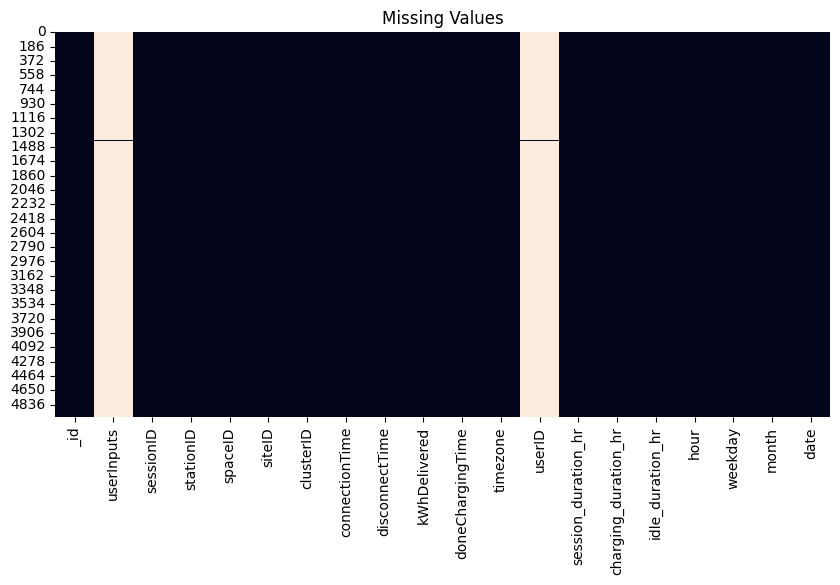

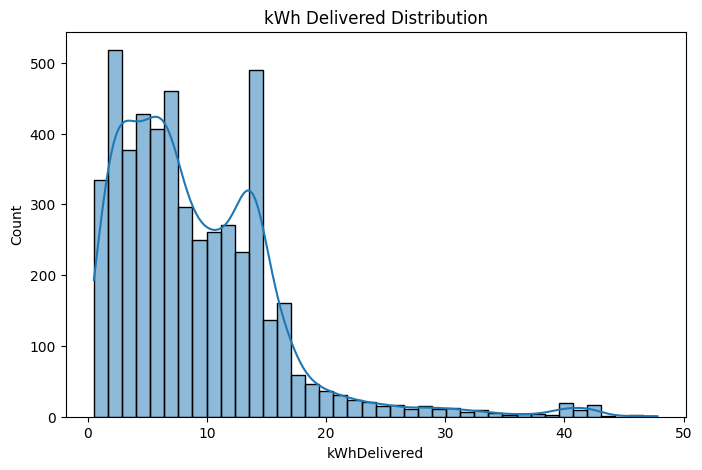

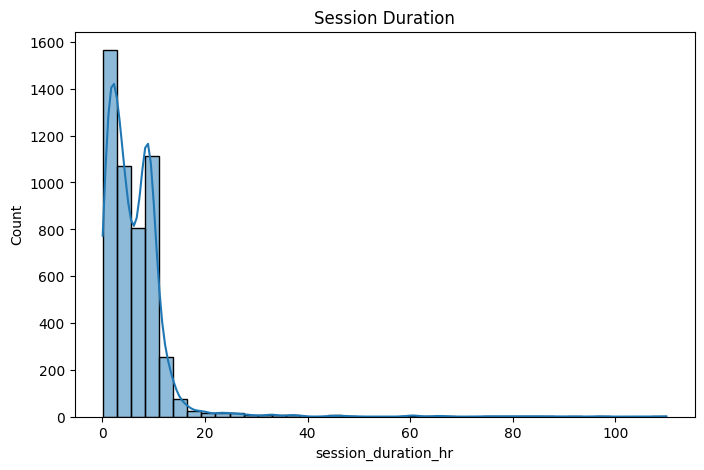

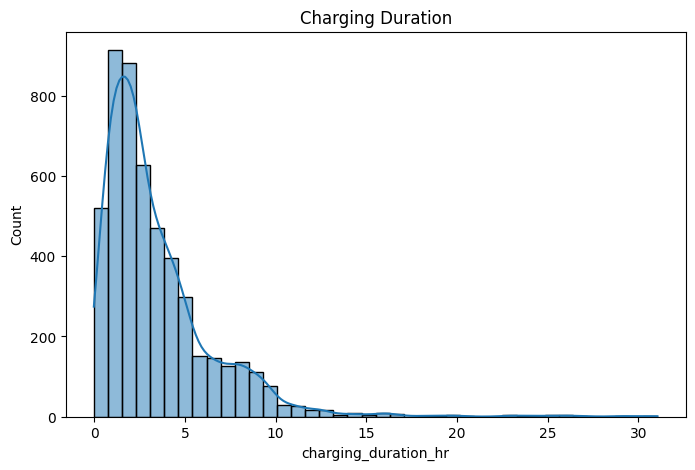

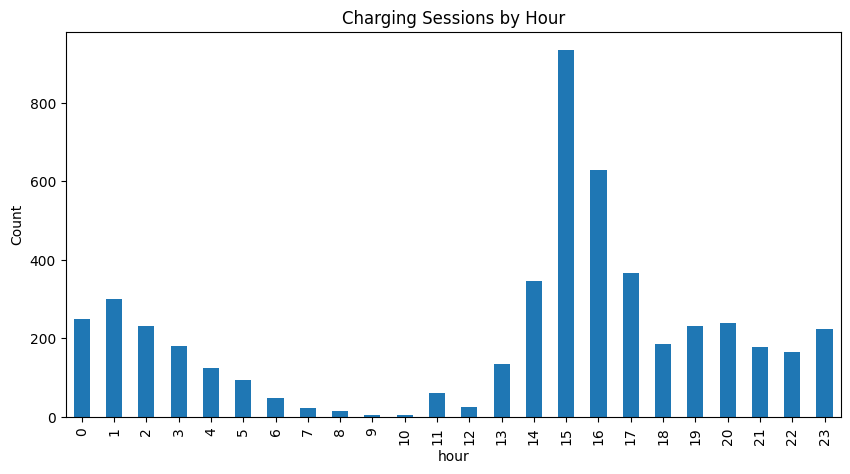

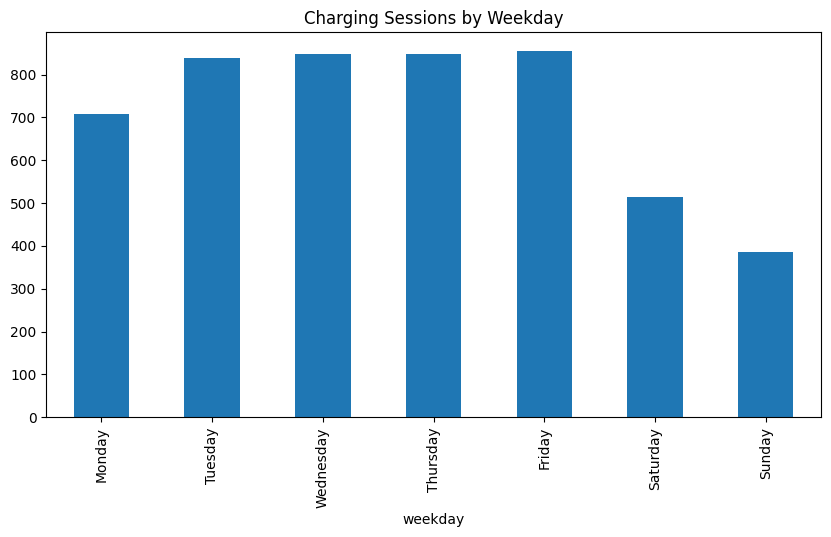

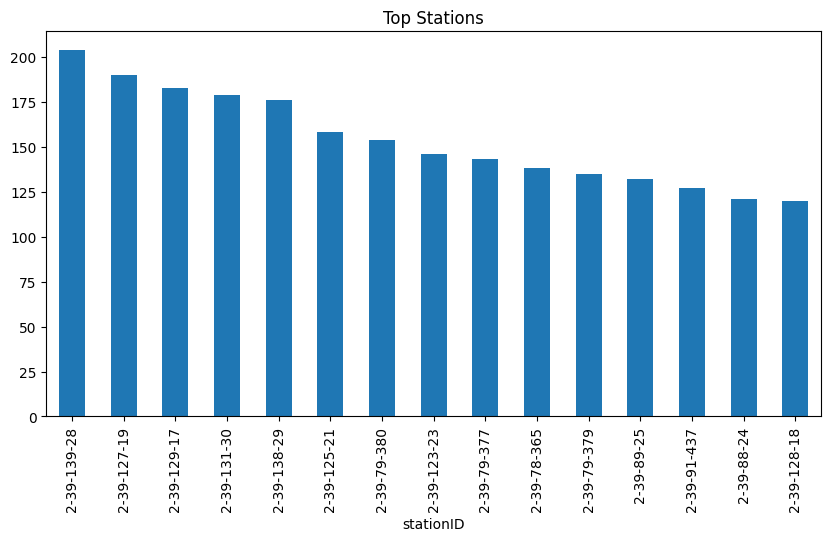

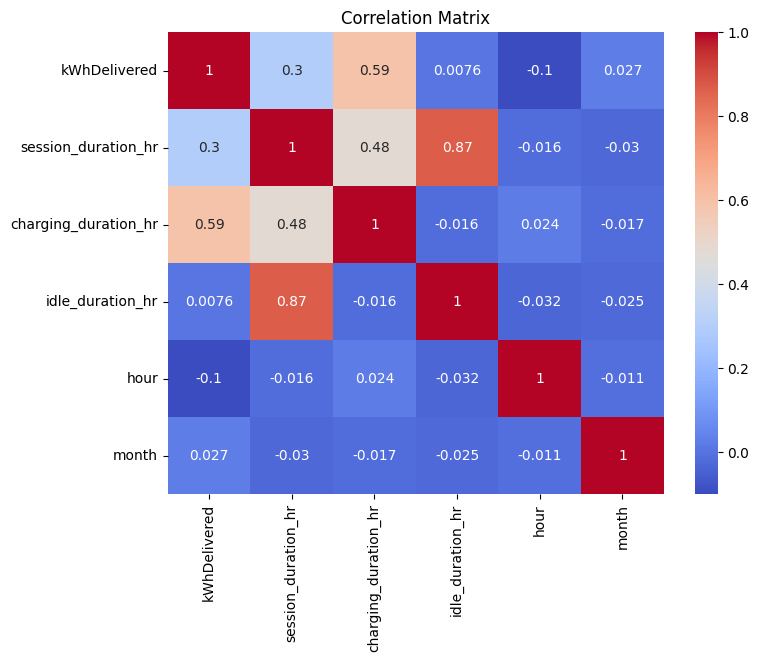

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("acn_clean.csv")

# ---------- BASIC INFO ----------
print(df.info())
print(df.describe())

# ---------- MISSING VALUES ----------
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

# ---------- KWH DELIVERED ----------
plt.figure(figsize=(8,5))
sns.histplot(df["kWhDelivered"], bins=40, kde=True)
plt.title("kWh Delivered Distribution")
plt.show()

# ---------- SESSION DURATION ----------
plt.figure(figsize=(8,5))
sns.histplot(df["session_duration_hr"], bins=40, kde=True)
plt.title("Session Duration")
plt.show()

# ---------- CHARGING DURATION ----------
plt.figure(figsize=(8,5))
sns.histplot(df["charging_duration_hr"], bins=40, kde=True)
plt.title("Charging Duration")
plt.show()

# ---------- HOURLY DEMAND ----------
hourly = df.groupby("hour").size()

plt.figure(figsize=(10,5))
hourly.plot(kind="bar")
plt.title("Charging Sessions by Hour")
plt.ylabel("Count")
plt.show()

# ---------- WEEKDAY DEMAND ----------
weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

weekday_counts = (
    df["weekday"]
    .value_counts()
    .reindex(weekday_order)
)

plt.figure(figsize=(10,5))
weekday_counts.plot(kind="bar")
plt.title("Charging Sessions by Weekday")
plt.show()

# ---------- TOP STATIONS ----------
top = df["stationID"].value_counts().head(15)

plt.figure(figsize=(10,5))
top.plot(kind="bar")
plt.title("Top Stations")
plt.show()

# ---------- CORRELATION ----------
num_cols = [
    "kWhDelivered",
    "session_duration_hr",
    "charging_duration_hr",
    "idle_duration_hr",
    "hour",
    "month"
]

plt.figure(figsize=(8,6))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

volume = pd.read_csv("urbanev/volume.csv")
occupancy = pd.read_csv("urbanev/occupancy.csv")
duration = pd.read_csv("urbanev/duration.csv")
price = pd.read_csv("urbanev/price.csv")
time_df = pd.read_csv("urbanev/time.csv")

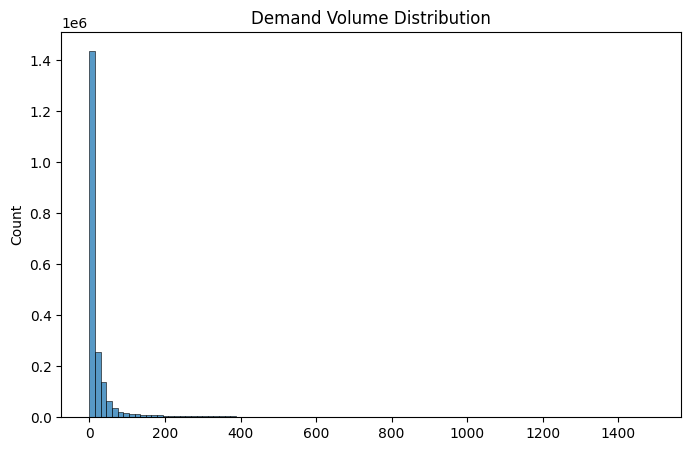

In [ ]:
vol = volume.drop(columns=["timestamp"])

plt.figure(figsize=(8,5))
sns.histplot(vol.values.flatten(), bins=100)
plt.title("Demand Volume Distribution")
plt.show()

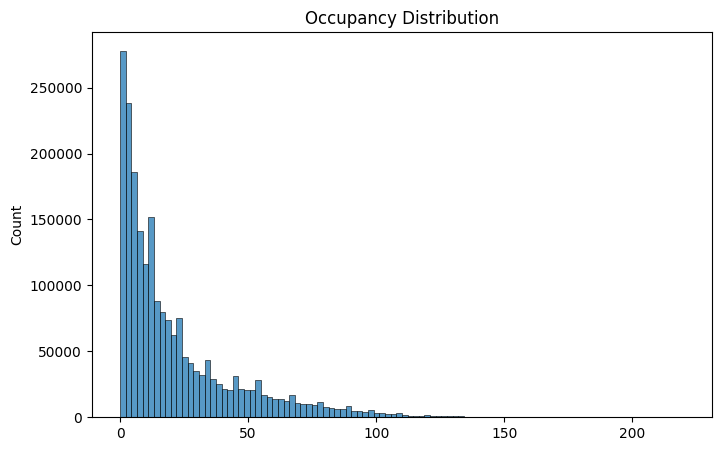

In [ ]:
occ = occupancy.drop(columns=["timestamp"])

plt.figure(figsize=(8,5))
sns.histplot(occ.values.flatten(), bins=100)
plt.title("Occupancy Distribution")
plt.show()

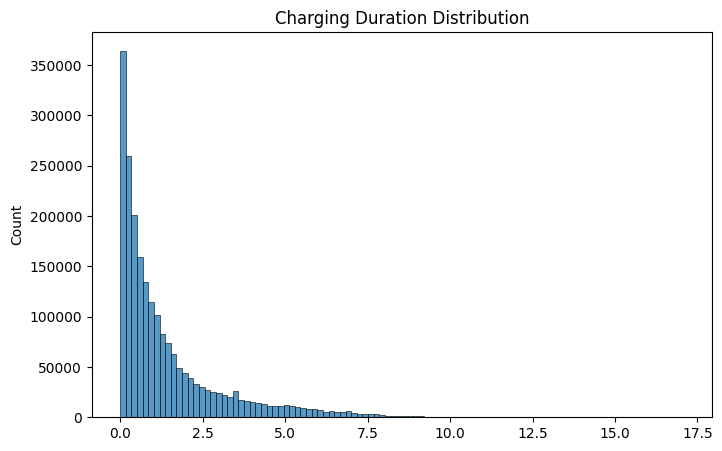

In [ ]:
dur = duration.drop(columns=["timestamp"])

plt.figure(figsize=(8,5))
sns.histplot(dur.values.flatten(), bins=100)
plt.title("Charging Duration Distribution")
plt.show()

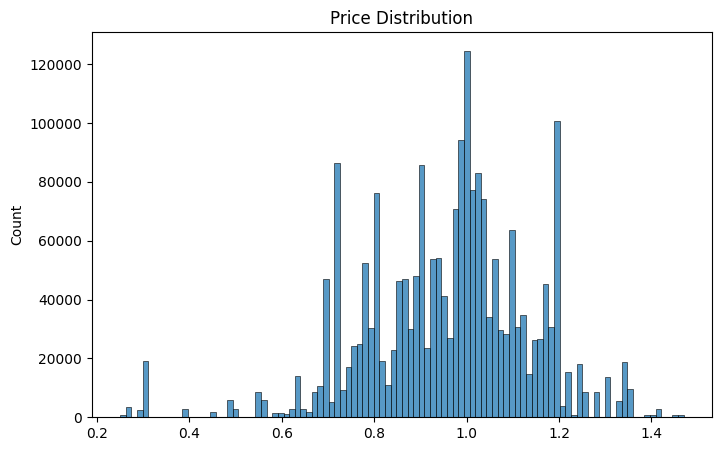

In [ ]:
pr = price.drop(columns=["timestamp"])

plt.figure(figsize=(8,5))
sns.histplot(pr.values.flatten(), bins=100)
plt.title("Price Distribution")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_35692\1715508180.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  volume["avg_volume"] = (


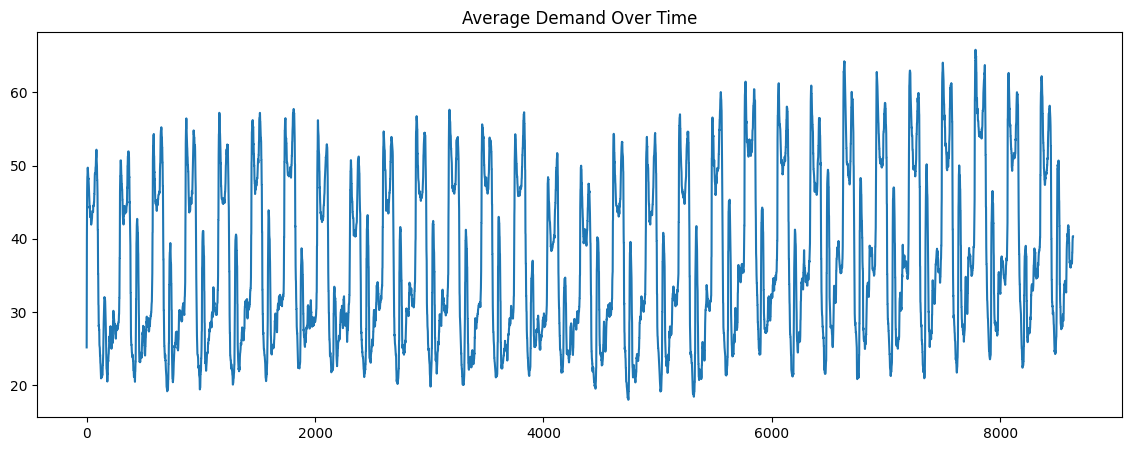

In [ ]:
volume["avg_volume"] = (
    volume.drop(columns=["timestamp"])
    .mean(axis=1)
)

plt.figure(figsize=(14,5))
plt.plot(volume["avg_volume"])
plt.title("Average Demand Over Time")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_35692\1204166398.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  occupancy["avg_occ"] = (


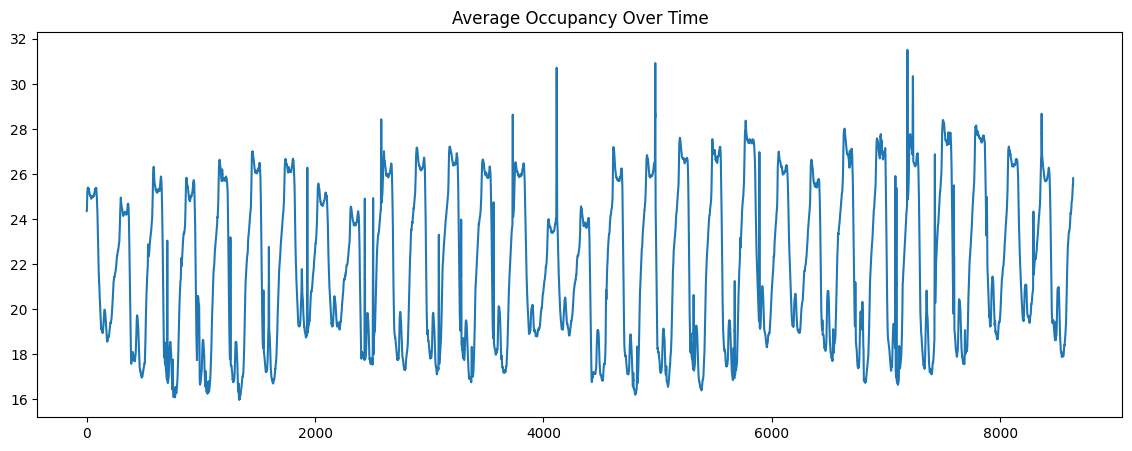

In [ ]:
occupancy["avg_occ"] = (
    occupancy.drop(columns=["timestamp"])
    .mean(axis=1)
)

plt.figure(figsize=(14,5))
plt.plot(occupancy["avg_occ"])
plt.title("Average Occupancy Over Time")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_35692\626793319.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  price["avg_price"] = (


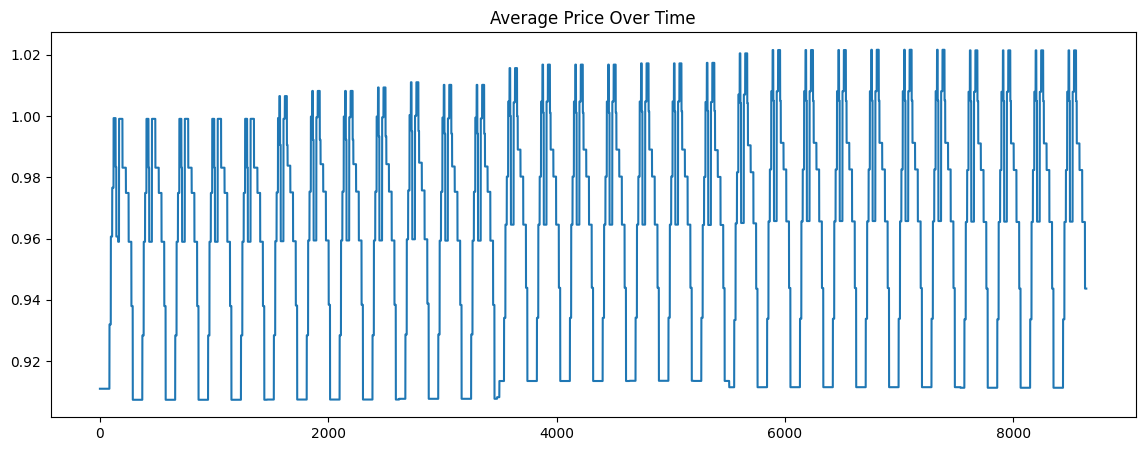

In [ ]:
price["avg_price"] = (
    price.drop(columns=["timestamp"])
    .mean(axis=1)
)

plt.figure(figsize=(14,5))
plt.plot(price["avg_price"])
plt.title("Average Price Over Time")
plt.show()

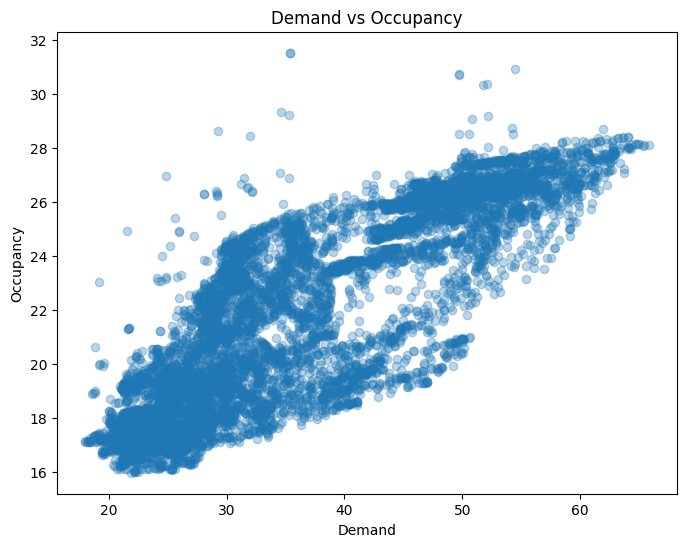

In [ ]:
demand = (
    volume.drop(columns=["timestamp"])
    .mean(axis=1)
)

occ = (
    occupancy.drop(columns=["timestamp"])
    .mean(axis=1)
)

plt.figure(figsize=(8,6))
plt.scatter(demand, occ, alpha=0.3)
plt.xlabel("Demand")
plt.ylabel("Occupancy")
plt.title("Demand vs Occupancy")
plt.show()

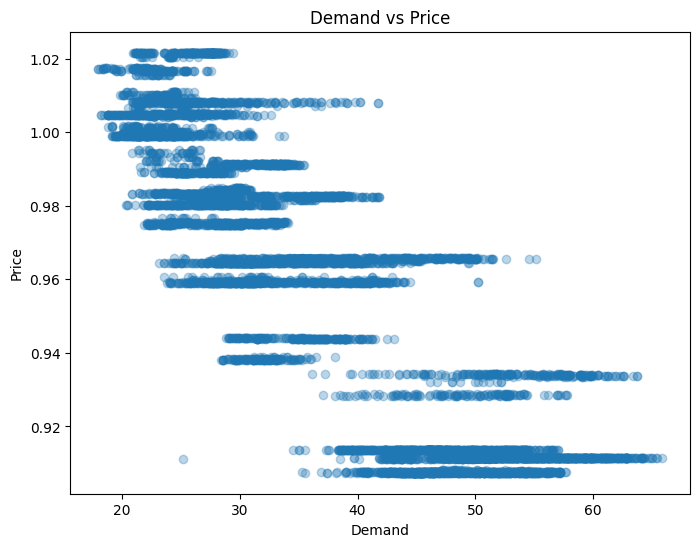

In [ ]:
price_avg = (
    price.drop(columns=["timestamp"])
    .mean(axis=1)
)

plt.figure(figsize=(8,6))
plt.scatter(demand, price_avg, alpha=0.3)
plt.xlabel("Demand")
plt.ylabel("Price")
plt.title("Demand vs Price")
plt.show()

In [ ]:
print(acn.info())
print(acn.describe())

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(acn.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [17]:
print("VOLUME")
print(volume.isnull().sum().sum())

print("OCCUPANCY")
print(occupancy.isnull().sum().sum())

print("DURATION")
print(duration.isnull().sum().sum())

print("PRICE")
print(price.isnull().sum().sum())

VOLUME
0
OCCUPANCY
0
DURATION
0
PRICE
0


In [16]:
print(dir())


['In', 'Out', 'PS1', 'REPLHooks', '_', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__session__', '__spec__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i2', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'demand', 'df', 'dur', 'duration', 'exit', 'get_ipython', 'get_last_command', 'hourly', 'hourly_occ', 'hourly_price', 'is_wsl', 'num_cols', 'occ', 'occupancy', 'open', 'original_ps1', 'pd', 'platform', 'plt', 'pr', 'price', 'price_avg', 'quit', 'sample', 'sns', 'sys', 'time_df', 'top', 'top_grids', 'vol', 'volume', 'weekday_counts', 'weekday_demand', 'weekday_order']


In [18]:
for name, df in {
    "Volume": volume,
    "Occupancy": occupancy,
    "Duration": duration,
    "Price": price
}.items():

    print("\n", name)
    print(df.describe())


 Volume
         timestamp          102          105          107          108  \
count  8640.000000  8640.000000  8640.000000  8640.000000  8640.000000   
mean   4320.500000     5.336029     6.656212     7.228926     7.373510   
std    2494.297496     1.153703     1.817421     2.520186     1.918755   
min       1.000000     2.041667     1.750000     1.750000     2.625000   
25%    2160.750000     4.483403     5.250000     5.250000     6.125000   
50%    4320.500000     5.250000     6.416667     7.000000     7.493889   
75%    6480.250000     6.125000     7.875000     8.750000     8.750000   
max    8640.000000     9.625000    11.958333    17.833333    12.541667   

               109          110          111          115          123  ...  \
count  8640.000000  8640.000000  8640.000000  8640.000000  8640.000000  ...   
mean      3.600911     4.352091     5.548345     0.647816     1.851793  ...   
std       1.597982     1.463044     1.341634     0.539588     0.970376  ...   
min     

In [19]:
merged = pd.DataFrame({
    "demand": volume["avg_volume"],
    "occupancy": occupancy["avg_occ"],
    "price": price["avg_price"]
})

In [8]:
merged = pd.DataFrame({
    "demand": volume["avg_volume"],
    "occupancy": occupancy["avg_occ"],
    "price": price["avg_price"]
})

In [20]:
merged.corr()

,demand,occupancy,price
demand,1.000000,0.840295,-0.862787
occupancy,0.840295,1.000000,-0.875036
price,-0.862787,-0.875036,1.000000


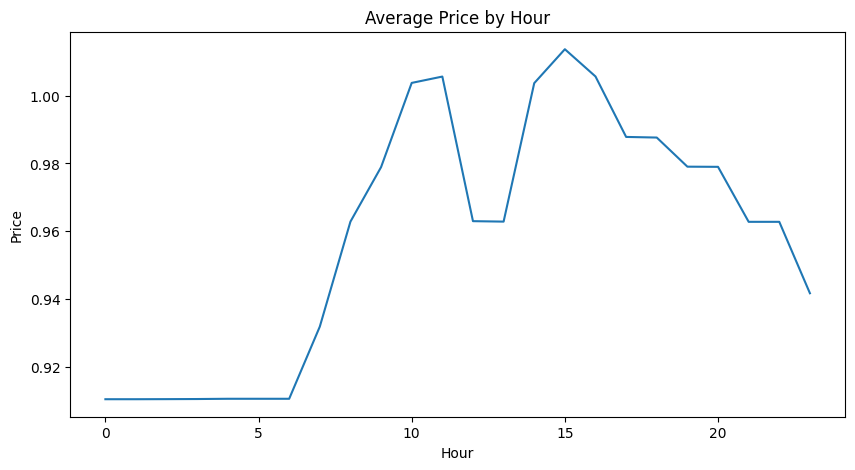

In [25]:
plt.figure(figsize=(10,5))
plt.plot(hourly.index, hourly["price"])
plt.title("Average Price by Hour")
plt.xlabel("Hour")
plt.ylabel("Price")
plt.show()

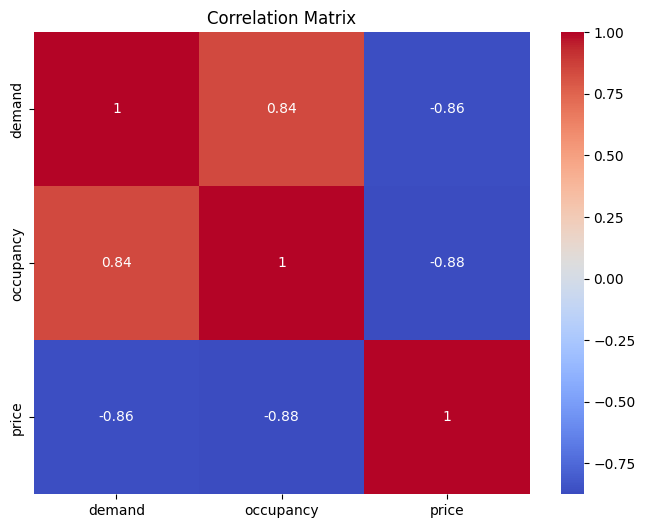

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(
    merged.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

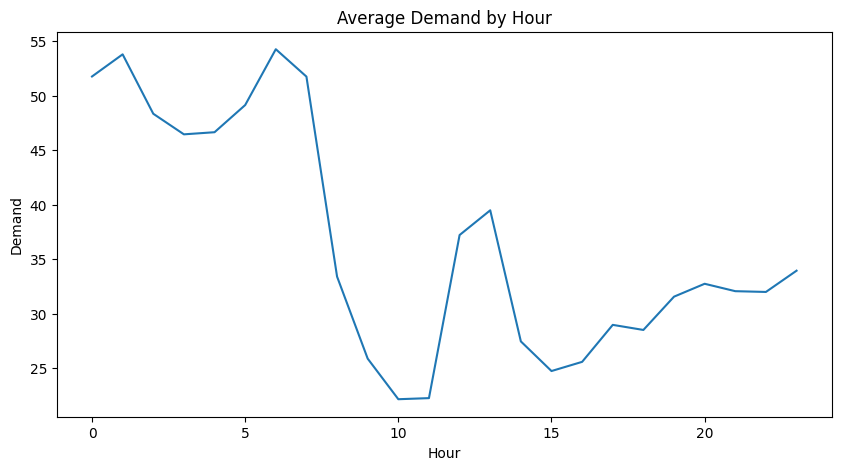

In [26]:
plt.figure(figsize=(10,5))
plt.plot(hourly.index, hourly["demand"])
plt.title("Average Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Demand")
plt.show()

In [ ]:
EDA ENDS HERE


In [10]:
import pandas as pd

volume = pd.read_csv("urbanev/volume.csv")
occupancy = pd.read_csv("urbanev/occupancy.csv")
price = pd.read_csv("urbanev/price.csv")
time_df = pd.read_csv("urbanev/time.csv")

volume_avg = (
    volume.drop(columns=["timestamp"])
    .mean(axis=1)
)

occupancy_avg = (
    occupancy.drop(columns=["timestamp"])
    .mean(axis=1)
)

price_avg = (
    price.drop(columns=["timestamp"])
    .mean(axis=1)
)

In [11]:
merged = pd.DataFrame({
    "demand": volume_avg,
    "occupancy": occupancy_avg,
    "price": price_avg
})

merged["hour"] = time_df["hour"]
merged["day"] = time_df["day"]
merged["month"] = time_df["month"]

merged["is_weekend"] = (
    merged["day"] >= 5
).astype(int)

merged["prev_price"] = merged["price"].shift(1)

merged = merged.dropna()

print(merged.shape)
merged.head()

(8639, 8)


,demand,occupancy,price,hour,day,month,is_weekend,prev_price
1,38.514720,24.356275,0.911018,0,19,6,1,0.911018
2,40.093327,24.643725,0.911018,0,19,6,1,0.911018
3,44.544098,24.923077,0.911018,0,19,6,1,0.911018
4,46.450680,25.072874,0.911018,0,19,6,1,0.911018
5,47.883763,25.238866,0.911018,0,19,6,1,0.911018


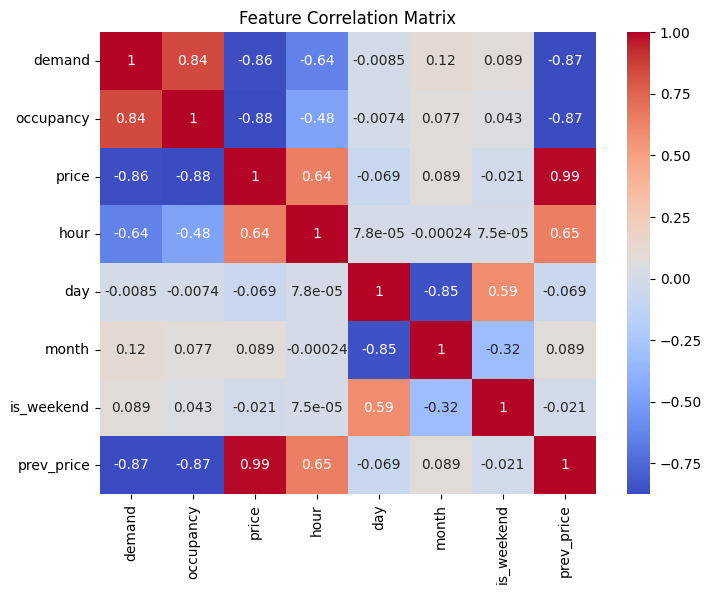

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    merged.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [13]:
X = merged[
    [
        "occupancy",
        "price",
        "hour",
        "day",
        "month",
        "is_weekend",
        "prev_price"
    ]
]

y = merged["demand"]

print(X.shape)
print(y.shape)

(8639, 7)
(8639,)


In [14]:
split_idx = int(len(merged) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (6911, 7)
Testing Set: (1728, 7)


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [16]:
y_pred = rf.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[40.75667133 51.4832711  54.54693847 55.58176521 56.40638448 56.57950688
 57.77460888 57.92006197 58.17617015 58.17617015]


In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE =", mae)
print("RMSE =", rmse)
print("R² =", r2)

MAE = 2.2181996006525933
RMSE = 3.1264012951010463
R² = 0.931187327563315


prev_price    0.798518
occupancy     0.072950
hour          0.067754
price         0.047186
day           0.012257
month         0.001058
is_weekend    0.000278
dtype: float64


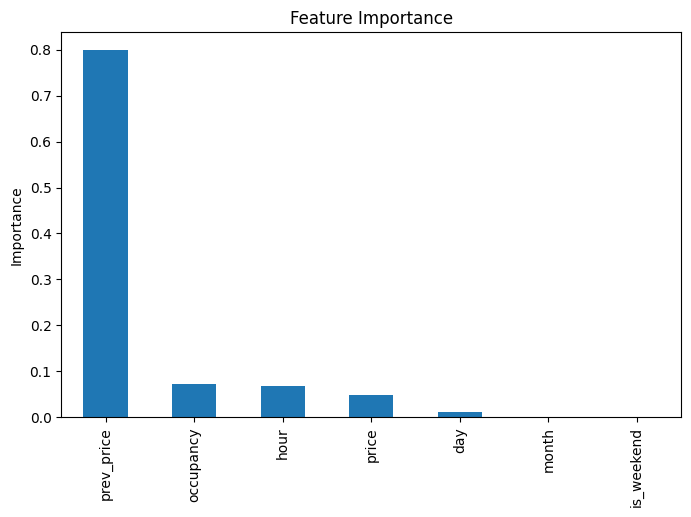

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

plt.figure(figsize=(8,5))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

In [19]:
results = X_test.copy()

results["actual_demand"] = y_test.values
results["predicted_demand"] = y_pred

results.to_csv(
    "demand_predictions.csv",
    index=False
)

print("Saved demand_predictions.csv")

Saved demand_predictions.csv


In [20]:
X_no_prev = merged[
    [
        "occupancy",
        "price",
        "hour",
        "day",
        "month",
        "is_weekend"
    ]
]

split_idx = int(len(merged) * 0.8)

X_train = X_no_prev.iloc[:split_idx]
X_test = X_no_prev.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

rf2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf2.fit(X_train, y_train)

y_pred2 = rf2.predict(X_test)

mae2 = mean_absolute_error(y_test, y_pred2)
rmse2 = mean_squared_error(y_test, y_pred2) ** 0.5
r22 = r2_score(y_test, y_pred2)

print("MAE =", mae2)
print("RMSE =", rmse2)
print("R² =", r22)

MAE = 2.2987124347756405
RMSE = 3.2828889042595955
R² = 0.9241262843057921
